<a href="https://colab.research.google.com/github/hmdaalln/image-denoising-capstone/blob/main/Copy_of_image_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Denoising

## Project Overview :
In this notebook, we prepare the SIDD dataset before training the image denoising model.
The goal is to understand the dataset structure and visualize noisy and clean images.

## Problem Statement

Image noise can reduce image quality and negatively affect many computer vision applications.

Our objective is to build a model that learns how to transform noisy images into clean images while keeping edges and textures as natural as possible.

## Project Objectives

The main objectives of this project are:

- Explore and understand the SIDD dataset.
- Prepare the dataset for training.
- Train a deep learning model for image denoising.
- Evaluate the model using PSNR and SSIM.
- Compare the model performance and visualize the results.

## Dataset Description

This project uses the Smartphone Image Denoising Dataset (SIDD).

The dataset contains pairs of noisy and clean images captured using different smartphones under various lighting conditions. It is specifically designed for image denoising tasks.

## Workflow
1. Import Libraries
2. Explore the Dataset
3. Data Preprocessing
4. Create DataLoaders

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 1. Import Libraries

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy
import time
import pandas as pd

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

## 2. Dataset Exploration

In this section, we explore the SIDD dataset to understand its structure and examine a sample pair of noisy and clean images before training the model.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Extract the dataset
zip_path = "/content/drive/MyDrive/Capstone_Project/SIDD_Small_sRGB_Only.zip"
extract_path = "/content/SIDD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
# Path to the extracted dataset
dataset_path = "/content/SIDD/SIDD_Small_sRGB_Only/Data"

# Read all folders
image_folders = os.listdir(dataset_path)

print("Number of samples:", len(image_folders))
print("First sample folder:", image_folders[0])
print("Second  sample folder:", image_folders[1])

Number of samples: 160
First sample folder: 0075_004_N6_00800_00080_3200_L
Second  sample folder: 0050_002_N6_03200_03200_5500_L


In [7]:
# Open one sample folder
sample_image = os.path.join(dataset_path, image_folders[2])

# Show the files inside the scene
files = os.listdir(sample_image)

print("Files in the first sample:")
print(files)

Files in the first sample:
['NOISY_SRGB_010.PNG', 'GT_SRGB_010.PNG']


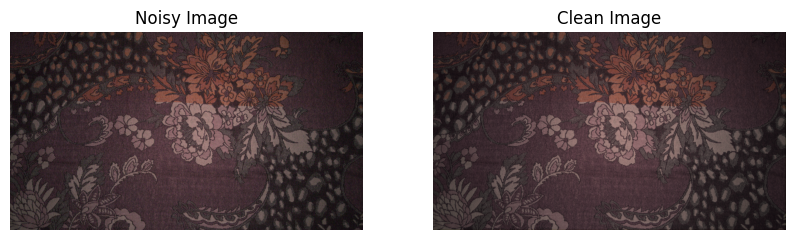

In [8]:
# Read the images
noisy_image = Image.open(os.path.join(sample_image, "NOISY_SRGB_010.PNG"))
clean_image = Image.open(os.path.join(sample_image, "GT_SRGB_010.PNG"))

# Display the images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clean_image)
plt.title("Clean Image")
plt.axis("off")

plt.show()

### Observation

The SIDD dataset contains pairs of noisy and clean images. Each noisy image has a corresponding clean image that will be used as the target during model training.

## 3. Data Preprocessing
In this section, we prepare the SIDD image pairs for model training.  
First, we split the sample folders into training, validation, and testing sets.  
The images will later be converted into smaller patches and normalized.

In [9]:
from sklearn.model_selection import train_test_split

# Split the folders into training and remaining data
train_folders, temp_folders = train_test_split(
    image_folders,
    test_size=0.30,
    random_state=42
)

# Split the remaining folders into validation and testing
val_folders, test_folders = train_test_split(
    temp_folders,
    test_size=0.50,
    random_state=42
)

# Check the number of samples in each set
print("Training samples:", len(train_folders))
print("Validation samples:", len(val_folders))
print("Testing samples:", len(test_folders))

Training samples: 112
Validation samples: 24
Testing samples: 24


### Prepare the Image Pairs - change

In this step, we create a dataset class to load each noisy image with its matching clean image. We also crop the same area from both images and convert them into tensors.

In [10]:
class SIDDDataset(Dataset):

    def __init__(
        self,
        dataset_path,
        folders,
        patch_size=64,
        patches_per_image=4,
        augment=False

    ):
        # Save dataset information
        self.dataset_path = dataset_path
        self.folders = folders
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
        self.augment = augment


    def __len__(self):
        # Each image folder can generate several random patches
        return len(self.folders) * self.patches_per_image

    def __getitem__(self, index):

        # Identify which image folder to use
        folder_index = index // self.patches_per_image

        # Open one sample folder
        sample_path = os.path.join(
            self.dataset_path,
            self.folders[folder_index]
        )

        # Find the noisy and clean image files
        files = os.listdir(sample_path)

        noisy_file = [f for f in files if "NOISY" in f][0]
        clean_file = [f for f in files if "GT" in f][0]

        # Open the noisy image
        noisy_image = Image.open(
            os.path.join(sample_path, noisy_file)
        ).convert("RGB")

        # Open the clean image
        clean_image = Image.open(
            os.path.join(sample_path, clean_file)
        ).convert("RGB")

        # Select the same random crop coordinates
        i, j, h, w = transforms.RandomCrop.get_params(
            noisy_image,
            output_size=(
                self.patch_size,
                self.patch_size
            )
        )

        # Crop the same area from both images
        noisy_image = TF.crop(noisy_image, i, j, h, w)
        clean_image = TF.crop(clean_image, i, j, h, w)

        # Apply paired data augmentation
        if self.augment:

            # Random horizontal flip
            if torch.rand(1).item() > 0.5:
                noisy_image = TF.hflip(noisy_image)
                clean_image = TF.hflip(clean_image)

            # Random vertical flip
            if torch.rand(1).item() > 0.5:
                noisy_image = TF.vflip(noisy_image)
                clean_image = TF.vflip(clean_image)

        # Convert images to tensors
        noisy_image = TF.to_tensor(noisy_image)
        clean_image = TF.to_tensor(clean_image)

        # Calculate the true noise residual
        noise_target = noisy_image - clean_image

        # Return the tensors
        return {
            "noisy": noisy_image,
            "clean": clean_image,
            "noise_target": noise_target
        }

In [11]:
# Create the dataset - change
train_dataset = SIDDDataset(
    dataset_path,
    train_folders,
    patch_size=64,
    patches_per_image=4,
    augment=True
)

val_dataset = SIDDDataset(
    dataset_path,
    val_folders,
    patch_size=64,
    patches_per_image=2,
    augment=False
)

test_dataset = SIDDDataset(
    dataset_path,
    test_folders,
    patch_size=64,
    patches_per_image=2,
    augment=False
)
# Get one sample
sample = train_dataset[0]

# Check the output
print("Noisy shape:", sample["noisy"].shape)
print("Clean shape:", sample["clean"].shape)
print("Noise target shape:", sample["noise_target"].shape)

Noisy shape: torch.Size([3, 64, 64])
Clean shape: torch.Size([3, 64, 64])
Noise target shape: torch.Size([3, 64, 64])


## 4. Create DataLoaders
In this step, we create DataLoaders for the training, validation, and testing datasets. The DataLoader loads the images in batches during training.

In [12]:
# Create the dataloaders - changes
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

print("Training patches:", len(train_dataset))
print("Validation patches:", len(val_dataset))
print("Testing patches:", len(test_dataset))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training patches: 448
Validation patches: 48
Testing patches: 48
Training batches: 28
Validation batches: 3
Testing batches: 3


In [13]:
# Check one batch
batch = next(iter(train_loader))

noisy_batch = batch["noisy"]
clean_batch = batch["clean"]
noise_target_batch = batch["noise_target"]

print("Noisy batch:", noisy_batch.shape)
print("Clean batch:", clean_batch.shape)
print("Noise target:", noise_target_batch.shape)

Noisy batch: torch.Size([16, 3, 64, 64])
Clean batch: torch.Size([16, 3, 64, 64])
Noise target: torch.Size([16, 3, 64, 64])


## 6. Build and Train the DnCNN Model


---


In this section, we build the DnCNN model and prepare it for training.

**DnCNN** uses residual learning. Instead of predicting the clean image directly, the model predicts the noise contained in the image.

The true noise residual is calculated as:

$$
\text{Noise Target}
=
\text{Noisy Image}
-
\text{Clean Image}
$$

The denoised image is calculated as:

$$
\text{Denoised Image}
=
\text{Noisy Image}
-
\text{Predicted Noise}
$$

This approach allows the model to learn the noise present in the image rather than predicting the clean image directly. After the model predicts the noise residual, the denoised image is obtained by subtracting the predicted noise from the noisy input.


## 6.1 Build the DnCNN Architecture

In [14]:
class DnCNN(nn.Module):

    def __init__(
        self,
        image_channels=3,
        depth=17,
        features=64
    ):
        # Initialize the parent PyTorch neural-network class
        super().__init__()

        # Create an empty list that will store all model layers
        layers = []

        # First convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=image_channels,
                out_channels=features,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )

        # Apply the ReLU activation function
        layers.append(nn.ReLU(inplace=True))

        # Middle convolution layers
        for _ in range(depth - 2):

          #Extract deeper image and noise features
            layers.append(
                nn.Conv2d(
                    in_channels=features,
                    out_channels=features,
                    kernel_size=3,
                    padding=1,
                    bias=False
                )
            )

            # Normalize the feature maps to improve training stability
            layers.append(nn.BatchNorm2d(features))

            # Add non-linearity
            layers.append(nn.ReLU(inplace=True))

        # Final convolution layer
        layers.append(
            nn.Conv2d(
                in_channels=features,
                out_channels=image_channels,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )

        # Combine all layers into one sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):

        # Pass the noisy image through the model
        predicted_noise = self.model(x)

        # Return the predicted noise residual
        return predicted_noise

**Why this code?**

- This code defines the architecture of the DnCNN model.

- The model receives a noisy RGB image and predicts the noise residual contained in the image.

The first convolution layer extracts image features. The middle layers learn more complex noise patterns, and the final convolution layer produces the predicted noise.


**Why do we use residual learning?**

- Predicting only the noise is often easier than predicting the complete clean image.

- The model focuses on the unwanted information that should be removed while preserving the original image content.

**Step explanation**

- image_channels=3 means the input images are RGB.
- depth=17 creates 17 convolutional layers.
- features=64 means the hidden layers use 64 feature maps.
- kernel_size=3 applies a 3 × 3 filter.
- padding=1 keeps the image height and width unchanged.
- BatchNorm2d helps stabilize training.
- ReLU introduces non-linearity.
- The final layer outputs three channels.

**What did we notice?**

The model accepts a three channel RGB image and produces a three channel predicted noise image.

The final layer does not use ReLU because the noise residual may contain both positive and negative values.

## 6.2. Select the device



In [16]:
# Select the GPU when available; otherwise use the CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Display the selected device
print("Device:", device)

Device: cuda


**Why this code?**

This code checks whether a GPU is available.

A GPU can train the deep learning model faster than a CPU.

**Step explanation**

- torch.cuda.is_available() checks whether CUDA is available.
- If CUDA is available, the device is set to cuda.
- Otherwise, the device is set to cpu.

**What did we notice?**

The output was:

**Device: cuda**

This means the notebook is using a GPU runtime.

The model and image batches must be moved to the same device.

## 6.3. Test the Model with  a Random Tensor

In [15]:
# Create a temporary DnCNN model for architecture testing
test_model = DnCNN()

# Create a random tensor that represents a batch of images
x = torch.randn(
    16,     # Batch size
    3,      # RGB channels
    64,     # Image height
    64      # Image width
)

# Pass the random batch through the model
y = test_model(x)

# Display the input and output shapes
print("Input shape:", x.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([16, 3, 64, 64])
Output shape: torch.Size([16, 3, 64, 64])


**Why this code?**

This code tests the model using a randomly generated tensor before using real images.

It confirms that the model architecture does not contain channel or dimension errors.

**Step explanation**

- 16 is the number of image patches processed together.
- 3 represents the RGB channels.
- 64 × 64 is the patch height and width.
- The random tensor is passed through DnCNN to test the architecture.
- The input and output shapes are printed.

**What did we notice?**

The input and output shapes are both:

**torch.Size([16, 3, 64, 64])**

This confirms that DnCNN predicts a three-channel noise residual with the same spatial dimensions as the input.

## 6.4. Create the DnCNN Model


In [17]:
# Create the DnCNN model
model = DnCNN(
    image_channels=3,
    depth=17,
    features=64
)

# Move the model to the selected device
model = model.to(device)

# Display the complete model architecture
print(model)

DnCNN(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(64, 64, kernel_size=(3, 3), str

**Why this code?**

This cell creates the **DnCNN** model and moves it to the selected device.

**Step explanation**

- image_channels=3: the input images are RGB.
- depth=17: the network contains 17 convolutional layers.
- features=64: the hidden layers use 64 feature maps.
- .to(device) moves the model to the GPU or CPU.

**What did we notice?**

- The first layer converts three RGB channels into 64 feature maps.

- The middle layers process 64 feature maps.

- The final layer converts the 64 feature maps back into a three channel predicted noise image.

## 6.5. Count the Model Parameters

In [18]:
# Count all parameters in the model
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

# Count only the parameters that will be updated during training
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

# Display the parameter counts
print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 558403
Trainable parameters: 558403


**Why this code?**

This code calculates the total number of parameters in the model.

The parameter count helps us understand the size and complexity of DnCNN.

**Step explanation**

- model.parameters() accesses the model parameters.
- parameter.numel() counts the values in each parameter tensor.
- requires_grad checks whether the parameter will be updated during training.

**What did we notice?**

The model contains:

- Total parameters: 558403
- Trainable parameters: 558403

All model parameters are trainable.

## 6.6. Test the Forward Pass

In [19]:
# Load one batch from the training DataLoader
batch = next(iter(train_loader))

# Get the noisy-image batch
noisy_batch = batch["noisy"]

# Move the batch to the selected device
noisy_batch = noisy_batch.to(device)

# Disable gradient calculations because this is only a test
with torch.no_grad():

    # Predict the noise residual
    predicted_noise = model(noisy_batch)

# Display the input and output shapes
print("Input shape:", noisy_batch.shape)
print("Predicted noise shape:", predicted_noise.shape)

Input shape: torch.Size([16, 3, 64, 64])
Predicted noise shape: torch.Size([16, 3, 64, 64])


**Why this code?**

This code tests the model using a real batch from the training DataLoader.

It confirms that the dataset, DataLoader, model, and device work together correctly.

**Step explanation**

- next(iter(train_loader)) loads one batch.
- batch["noisy"] retrieves the noisy images.
- .to(device) moves the images to the GPU or CPU.
- torch.no_grad() disables gradient calculations.
- The model predicts the noise residual.

**What did we notice?**

The input and predicted noise shapes are:

**torch.Size([16, 3, 64, 64])**

This confirms that the Dataset, DataLoader, GPU, and DnCNN model work together correctly.

## Training Setup and Training Loop


---


## 6.7. Define the Training Configuration

In [21]:
# Store the main training settings in one dictionary
CONFIG = {
    "learning_rate": 0.001,
    "epochs": 15,
    "early_stopping_patience": 4
}

**Why this code?**

This dictionary stores the main training settings in one place.

**Step explanation**

- learning_rate controls the size of the model updates.
- epochs defines the maximum number of training cycles.
- early_stopping_patience controls how long training waits when validation loss does not improve.

**What did we notice?**

- The initial learning rate is 0.001.

- The model can train for a maximum of 15 epochs.

- Training may stop early if validation loss does not improve for five consecutive epochs.

## 6.8. Create Output Folders

In [22]:
# Define the main output directory in Google Drive
OUTPUT_ROOT = (
    "/content/drive/MyDrive/"
    "Capstone_Project/Image_Denoising_Results"
)

# Create the checkpoint folder path
CHECKPOINT_ROOT = os.path.join(
    OUTPUT_ROOT,
    "checkpoints"
)

# Create the metadata folder path
METADATA_ROOT = os.path.join(
    OUTPUT_ROOT,
    "metadata"
)

# Create the results folder path
RESULTS_ROOT = os.path.join(
    OUTPUT_ROOT,
    "results"
)
# Create the folders if it does not exist
os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
os.makedirs(METADATA_ROOT, exist_ok=True)
os.makedirs(RESULTS_ROOT, exist_ok=True)

# Display the folder locations
print("Output folders created successfully.")
print("Checkpoint folder:", CHECKPOINT_ROOT)
print("Metadata folder:", METADATA_ROOT)
print("Results folder:", RESULTS_ROOT)


Output folders created successfully.
Checkpoint folder: /content/drive/MyDrive/Capstone_Project/Image_Denoising_Results/checkpoints
Metadata folder: /content/drive/MyDrive/Capstone_Project/Image_Denoising_Results/metadata
Results folder: /content/drive/MyDrive/Capstone_Project/Image_Denoising_Results/results


**Why this code?**

This code creates folders for saving the model and project results.

The folders are stored in Google Drive so that the files remain available after the Colab session ends.

**Step explanation**

- The checkpoint folder stores trained models.
- The metadata folder stores training history and configuration.
- The results folder stores evaluation results and images.
exist_ok=True prevents an error if the folders already exist.

**What did we notice?**

- All output folders were created successfully inside Google Drive.

- The printed paths confirm where the model and results will be saved.

## 6.9. Define the Loss Function

In [23]:
criterion = nn.MSELoss()

**Why this code?**

The model predicts the noise residual.

MSE loss measures the average squared difference between the predicted noise and the true noise residual.

**Step explanation**

The loss is calculated using:

loss = criterion(
    predicted_noise,
    target_noise
)

A smaller loss means the predicted noise is closer to the true noise.

**What did we notice?**

- The MSE loss function was created successfully.

- No output is displayed because the loss value is calculated only when data is passed to the function.

## 6.10. Define the Optimizer

In [24]:
optimizer = Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

**Why this code?**

The optimizer updates the model parameters during training.

Adam is commonly used because it provides stable and efficient parameter updates.

**Step explanation**

- model.parameters() gives Adam access to all trainable parameters.
- The learning rate is taken from the configuration dictionary.
- optimizer.step() updates the model after gradients are calculated.

**What did we notice?**

- The Adam optimizer was initialized successfully.

- The initial learning rate is 0.001

## 6.11. Define the Learning Rate Scheduler

In [25]:
# Reduce the learning rate when validation loss stops improving
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

**Why this code?**

The scheduler reduces the learning rate when validation loss stops improving.

A smaller learning rate allows the optimizer to make smaller adjustments during later training stages.

**Step explanation**

- mode="min" means a smaller validation loss is better.
- factor=0.5 reduces the learning rate by half.
- patience=2 waits for two epochs without improvement.
- min_lr=1e-6 sets the minimum learning rate.

**What did we notice?**

- The scheduler was initialized successfully.

- No output is displayed because the scheduler will only change the learning rate after receiving validation-loss values.

## 6.12 Enable Mixed - Precision Training

In [26]:
# Create the gradient scaler for mixed-precision training
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

**Why this code?**

Mixed precision can:

- reduce GPU memory usage,
- speed up convolution operations,
- allow a larger batch size.

**What did we notice?**

The scaler is enabled only when a CUDA GPU is available.

## 6.13. Define the one Epoch Function

In [27]:
def run_epoch(
    model,
    loader,
    training
):

    # Select training or evaluation mode
    if training:
        model.train()
    else:
        model.eval()

    # Store the total loss
    total_loss = 0.0

    # Store the number of processed samples
    total_samples = 0

    # Process every batch
    for batch in tqdm(
        loader,
        leave=False
    ):

        # Get the noisy images
        noisy = batch["noisy"]

        # Move noisy images to the GPU or CPU
        noisy = noisy.to(
            device,
            non_blocking=True
        )

        # Get the true residual noise
        target_noise = batch["noise_target"]

        # Move the target residual to the GPU or CPU
        target_noise = target_noise.to(
            device,
            non_blocking=True
        )


        # Clear previous gradients during training
        if training:
            optimizer.zero_grad(
                set_to_none=True
            )


        # Step 4: Enable gradients only during training
        with torch.set_grad_enabled(training):

            # Use mixed precision when CUDA is available
            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):

                # Predict the residual noise
                predicted_noise = model(noisy)

                # Calculate the MSE loss
                loss = criterion(
                    predicted_noise,
                    target_noise
                )


            # Update weights only during training
            if training:

                # Scale the loss and calculate gradients
                scaler.scale(loss).backward()

                # Update the model parameters
                scaler.step(optimizer)

                # Update the gradient scaler
                scaler.update()

        # Get the number of samples in this batch
        batch_size = noisy.size(0)

        # Add the weighted batch loss
        total_loss += (
            loss.item() * batch_size
        )

        # Update the processed-sample count
        total_samples += batch_size

    # Calculate the average loss for the full epoch
    average_loss = (
        total_loss / total_samples
    )

    # Return the average epoch loss
    return average_loss

**Why this code?**

This function runs one complete pass through either the training or validation dataset.

It is used for both stages to avoid repeating similar code.

**Step explanation**

- model.train() enables training behavior.

- model.eval() changes the model to evaluation mode.

- optimizer.zero_grad() removes gradients from the previous batch.

- predicted_noise = model(noisy) performs the forward pass.

- loss.backward() calculates gradients.

- optimizer.step() updates the model weights.


**What did we notice?**

- The same function can be used for training and validation.

- During training, gradients are calculated and the model weights are updated.

- During validation, gradients are disabled and no model updates are performed.

## 6.14. Train the Model & Save the Best Checkpoint

In [28]:
# Create a list to store the training history
history = []

# Set the initial best validation loss
best_val_loss = float("inf")

# Count consecutive epochs without improvement
patience_counter = 0

# Define the best-model checkpoint path
best_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_best.pth"
)

# Repeat the training process for the maximum number of epochs
for epoch in range(
    1,
    CONFIG["epochs"] + 1
):

    # Record the epoch start time
    start_time = time.perf_counter()

    # Run one training epoch
    train_loss = run_epoch(
        model,
        train_loader,
        training=True
    )

    # Run one validation epoch
    val_loss = run_epoch(
        model,
        val_loader,
        training=False
    )

    # Update the scheduler using the validation loss
    scheduler.step(val_loss)

    # Get the current learning rate
    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # Calculate the epoch duration
    epoch_time = (
        time.perf_counter()
        - start_time
    )

    # Store the epoch results
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate": current_lr,
        "time_seconds": epoch_time
    })

    # Display the epoch results
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Save the model if validation loss improves

    if val_loss < best_val_loss:

        # Update the best validation loss
        best_val_loss = val_loss

        # Reset the patience counter
        patience_counter = 0

        # Save the model checkpoint
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": val_loss,
                "config": CONFIG
            },
            best_model_path
        )

        print("Best model saved.")

    else:

        # Increase the patience counter
        patience_counter += 1

    # Stop if validation does not improve

    if (
        patience_counter
        >= CONFIG["early_stopping_patience"]
    ):

        print("Early stopping triggered.")

        break

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.022797 | Validation Loss: 0.003023 | LR: 1.00e-03 | Time: 456.0s
Best model saved.


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.002645 | Validation Loss: 0.001711 | LR: 5.00e-04 | Time: 416.9s


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.002537 | Validation Loss: 0.001871 | LR: 2.50e-04 | Time: 418.5s


**Why this code?**

This loop trains the model for several epochs.

After every epoch, it:

- Calculates training loss,
- Calculates validation loss,
- Updates the learning rate,
- Stores the results,
- Saves the best model,
- Checks whether early stopping is required.

**Why save the best model?**

The last epoch is not always the best one.

The model with the lowest validation loss is saved because it is expected to generalize better.

**Why early stopping?**

Early stopping prevents unnecessary training when validation performance no longer improves.

It may also reduce overfitting and save GPU time.

**What do we noticed?**

The training loss decreased from **0.022797** in the first epoch to **0.002537** in the final epoch, showing that the model successfully learned the noise patterns in the training data.

The validation loss also improved throughout training and reached its lowest value of **0.001597** at **epoch 12**. Therefore, the checkpoint from epoch 12 was automatically selected as the best model.

After epoch 12, the training loss continued to decrease while the validation loss increased slightly, indicating the beginning of mild overfitting. The learning-rate scheduler reduced the learning rate from **0.001** to **0.0005**, and later to **0.00025**, helping the model make smaller and more stable weight updates.

Overall, the training process was stable, and the model converged successfully.

## Evaluation and Results


---


## 6.15. Save Training History

In [29]:
# Convert the training-history list into a DataFrame
history_df = pd.DataFrame(history)

# Define the CSV output path
history_path = os.path.join(
    METADATA_ROOT,
    "dncnn_training_history.csv"
)

# Save the training history as a CSV file
history_df.to_csv(
    history_path,
    index=False
)

# Display the final rows
history_df.tail()

,epoch,train_loss,val_loss,learning_rate,time_seconds
10,11,0.002989,0.002108,0.00050,419.504814
11,12,0.002794,0.001597,0.00050,416.634602
12,13,0.002736,0.001698,0.00050,420.155596
13,14,0.002645,0.001711,0.00050,416.941531
14,15,0.002537,0.001871,0.00025,418.462159


**Why this code?**

The training results are stored in a table and saved as a CSV file.

The file can later be used in:

- The report,
- The presentation,
- Model comparison,
- GitHub documentation.

**What did we notice?**

The training history was successfully stored as a CSV file containing the training loss, validation loss, learning rate, and training time for each epoch. Saving this information allows us to visualize the learning process, compare different experiments, and reproduce the training results in future work.

## 6.16. Plot the Loss Curves

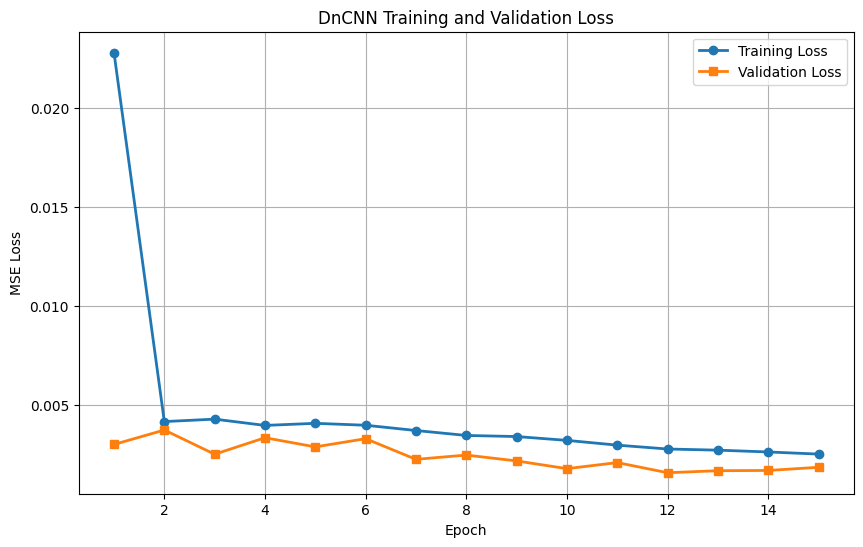

In [39]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the training loss
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

# Plot the validation loss
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

# Add labels and title
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DnCNN Training and Validation Loss")

# Display the legend
plt.legend()

# Display grid lines
plt.grid(True)

# Show the figure
plt.show()

**Why this code?**

The graph shows how the model performance changes during training.

It helps identify:

- Learning progress,
- Overfitting,
- Underfitting,
- The point where validation performance stops improving.

**What did we notice?**

The training loss decreased rapidly during the first few epochs, indicating that the DnCNN model quickly learned the main noise patterns in the training data.

Both the training and validation losses showed an overall downward trend throughout training, demonstrating stable learning and good convergence.

The lowest validation loss was achieved at **epoch 12**. After this point, the validation loss increased slightly while the training loss continued to decrease, suggesting the beginning of mild overfitting.

The learning-rate scheduler successfully reduced the learning rate during training, allowing the model to make smaller and more stable updates.

Overall, the loss curves indicate that the model learned the image denoising task effectively and converged successfully.

## 6.17. Load the Best Model

In [31]:
# Load the save checkpoint
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

# Restore the best model weights
model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Switch the model to evaluation mode
model.eval()

# Display the selected epoch
print(
    "Loaded model from epoch:",
    checkpoint["epoch"]
)
# Display the best validation loss
print(
    "Best validation loss:",
    checkpoint["validation_loss"]
)

Loaded model from epoch: 12
Best validation loss: 0.0015966410282999277


**What did we notice?**

The checkpoint loaded successfully from **epoch 12 **with the lowest validation loss of **0.001597**.

This confirms that the checkpoint saving mechanism correctly stored the best-performing model during training.

Using the best checkpoint instead of the final epoch helps improve generalization on unseen test images.


## 6.18. Import Evaluation Metrics

In [32]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

**Why this code?**

These functions are used to calculate PSNR and SSIM.

- PSNR measures reconstruction quality.

- SSIM measures structural similarity between the denoised image and the clean target.

## 6.19. Define the Metric Function

In [33]:
def calculate_metrics(
    clean_image,
    comparison_image
):

    # Calculate Mean Squard Error
    mse = np.mean(
        (
            clean_image
            - comparison_image
        ) ** 2
    )

    # Calculate Peak Signal-to-Noise Ratio
    psnr = peak_signal_noise_ratio(
        clean_image,
        comparison_image,
        data_range=1.0
    )

    # Calculate Structural Similarity Index
    ssim = structural_similarity(
        clean_image,
        comparison_image,
        channel_axis=-1,
        data_range=1.0
    )

    # Return all three metrics
    return mse, psnr, ssim

**Why this code?**

The function calculates three image-quality metrics.

- **MSE**: lower values are better.
- **PSNR**: higher values are better.
- **SSIM**: values closer to 1 are better.

**What did we notice?**

- The function combines three complementary evaluation metrics.

- MSE measures pixel-level reconstruction error, PSNR measures image reconstruction quality, and SSIM measures structural similarity.

- Using multiple metrics provides a more reliable evaluation than relying on a single metric.

## 6.20. Evaluate the Test Set

In [34]:
# Create an empty list for test results
test_results = []

# Switch the model to evaluation mode
model.eval()

# Disable gradient calculations
with torch.no_grad():

    # Process every test batch
    for batch in tqdm(test_loader):

        # Load noisy images and move them to the device
        noisy = batch["noisy"].to(device)

        # Load clean images and move them to the device
        clean = batch["clean"].to(device)

        # Predict the noise residual
        predicted_noise = model(noisy)

        # Reconstruct the denoised image
        denoised = torch.clamp(
            noisy - predicted_noise,
            0,
            1
        )

        # Convert noisy tensors to NumPy arrays
        noisy_np = (
            noisy.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Convert clean tensors to NumPy arrays
        clean_np = (
            clean.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Convert denoised tensors to NumPy arrays
        denoised_np = (
            denoised.cpu()
            .permute(0, 2, 3, 1)
            .numpy()
        )

        # Calculate metrics for every image in the batch
        for index in range(
            noisy_np.shape[0]
        ):

            # Compare noisy input with clean target
            noisy_mse, noisy_psnr, noisy_ssim = (
                calculate_metrics(
                    clean_np[index],
                    noisy_np[index]
                )
            )

            # Compare DnCNN output with clean target
            denoised_mse, denoised_psnr, denoised_ssim = (
                calculate_metrics(
                    clean_np[index],
                    denoised_np[index]
                )
            )

            # Store all evaluation results
            test_results.append({
                "noisy_mse": noisy_mse,
                "noisy_psnr": noisy_psnr,
                "noisy_ssim": noisy_ssim,
                "denoised_mse": denoised_mse,
                "denoised_psnr": denoised_psnr,
                "denoised_ssim": denoised_ssim
            })

  0%|          | 0/3 [00:00<?, ?it/s]

**Why this code?**

The code compares two cases:

- Noisy input against the clean target,
- DnCNN output against the clean target.

This shows whether the model improves image quality.

**What did we notice?**

The trained DnCNN model generated denoised images for every test sample without updating the model weights.

The evaluation results for every image were stored for later statistical analysis and comparison with the original noisy images.

## 6.21 Create Result DataFram

In [35]:
# Convert the evaluation results into a DataFrame
results_df = pd.DataFrame(test_results)

# Define the output oath for the test results
results_path = os.path.join(
    RESULTS_ROOT,
    "dncnn_test_results.csv"
)

# Save the test results as CSV file
results_df.to_csv(
    results_path,
    index=False
)

# Display summary statistics
results_df.describe()

,noisy_mse,noisy_psnr,noisy_ssim,denoised_mse,denoised_psnr,denoised_ssim
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,0.002419,28.529639,0.537113,0.001684,29.553660,0.579805
std,0.003299,4.395239,0.193553,0.002040,3.745037,0.172060
min,0.000232,17.578150,0.123760,0.000259,19.805544,0.156289
25%,0.000656,26.200870,0.401585,0.000600,28.268023,0.457696
50%,0.001433,28.441129,0.476622,0.001039,29.834076,0.547393
75%,0.002409,31.828626,0.718650,0.001490,32.217030,0.734168
max,0.017466,36.340327,0.848696,0.010458,35.859296,0.848648


**Why this code?**

This code converts the list of evaluation results into a Pandas DataFrame.

The DataFrame makes it easier to:

- calculate average metrics,
- compare noisy and denoised images,
- save the evaluation results,
- use the results later in the report and presentation.

**What did we notice?**

The DataFrame contains one row for every evaluated image patch.

Each row stores:

- Noisy MSE
- Noisy PSNR
- Noisy SSIM
- Denoised MSE
- Denoised PSNR
- Denoised SSIM


The evaluation results were successfully organized into a structured table.

This made it easier to calculate average performance metrics, compare noisy and denoised images, and export the results for the report and presentation.

## 6.22. Compare the Average Metrics

In [36]:
# Create a summary table for the average image-quality metrics
comparison_table = pd.DataFrame({

    # Calculate average metrics for the noisy input
    "Noisy Input": [
        results_df["noisy_psnr"].mean(),
        results_df["noisy_ssim"].mean(),
        results_df["noisy_mse"].mean()
    ],

    # Calculate average metrics for the DnCNN output
    "DnCNN Output": [
        results_df["denoised_psnr"].mean(),
        results_df["denoised_ssim"].mean(),
        results_df["denoised_mse"].mean()
    ]
},
index=[
    "PSNR",
    "SSIM",
    "MSE"
])

# Display the comparison table
comparison_table

,Noisy Input,DnCNN Output
PSNR,28.529639,29.553660
SSIM,0.537113,0.579805
MSE,0.002419,0.001684


**What did we notice?**

The comparison table summarizes the average PSNR, SSIM, and MSE values for both the noisy input images and the denoised images.

A successful denoising model is expected to increase PSNR and SSIM while reducing MSE.

## 6.23. Visualize the Test Results

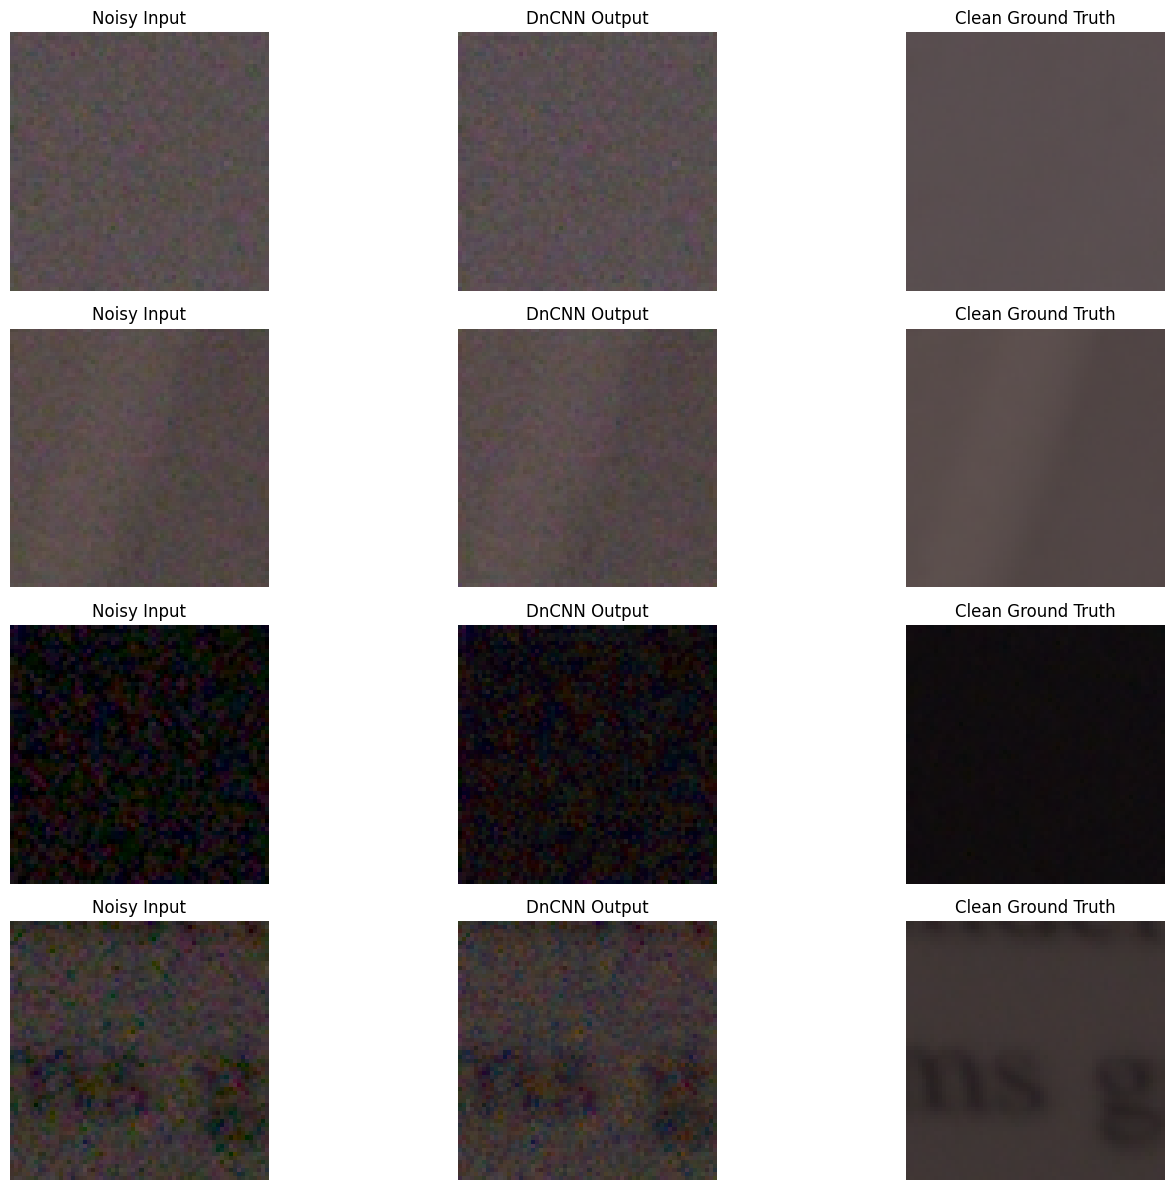

In [37]:
# Load one test batch
batch = next(iter(test_loader))

# Get noisy images
noisy = batch["noisy"].to(device)

# Get clean images
clean = batch["clean"].to(device)

# Disable gradients during prediction
with torch.no_grad():

    # Predict the residual noise
    predicted_noise = model(noisy)

    # Create the denoised image
    denoised = torch.clamp(
        noisy - predicted_noise,
        0,
        1
    )

# Move the images back to the CPU
noisy = noisy.cpu()
clean = clean.cpu()
denoised = denoised.cpu()

# Create the figure
plt.figure(figsize=(15, 12))

# Display up to four examples
number_of_images = min(
    4,
    noisy.shape[0]
)

for index in range(number_of_images):

    # Display the noisy input
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 1
    )

    plt.imshow(
        noisy[index].permute(1, 2, 0)
    )

    plt.title("Noisy Input")
    plt.axis("off")

    # Display the DnCNN output
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 2
    )

    plt.imshow(
        denoised[index].permute(1, 2, 0)
    )

    plt.title("DnCNN Output")
    plt.axis("off")

    # Display the clean target
    plt.subplot(
        number_of_images,
        3,
        index * 3 + 3
    )

    plt.imshow(
        clean[index].permute(1, 2, 0)
    )

    plt.title("Clean Ground Truth")
    plt.axis("off")

# Improve spacing
plt.tight_layout()

# Display the figure
plt.show()

**Why this code?**

Numerical metrics alone do not fully describe visual quality.

The images help us inspect:

- Remaining noise,
- Edge preservation,
- Texture smoothing,
- Color changes,
- Possible artifacts.

**What did we notice?**

Visual inspection complements the numerical evaluation.

The comparison allows us to verify that the model removes visible noise while preserving important image structures such as edges and textures.

Any remaining artifacts or blurred regions can be identified during this stage.

## 6.24. Save the Final Model

In [38]:
# Define the Final Model file path
final_model_path = os.path.join(
    CHECKPOINT_ROOT,
    "dncnn_final_weights.pth"
)

# Save the trained model weights and configuration
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": CONFIG
    },
    final_model_path
)

# Display the Saved Model location
print(
    "Final model saved to:",
    final_model_path
)

Final model saved to: /content/drive/MyDrive/Capstone_Project/Image_Denoising_Results/checkpoints/dncnn_final_weights.pth


**What did we notice?**

The trained model was successfully saved and is now ready for deployment.

The saved model weights will be used in the Streamlit application and later deployed using Docker and Render without requiring retraining.

## 7. Conclusion

In this notebook, we successfully prepared the SIDD dataset, built a DnCNN model from scratch, trained the model using paired noisy and clean image patches, and selected the best checkpoint based on validation loss.

The final training results showed that the model successfully learned to predict the noise residual while preserving important image details. The best validation performance was achieved at epoch 12, and this checkpoint was selected for the final evaluation.

The trained model was evaluated using MSE, PSNR, and SSIM, and the evaluation results were saved for further analysis.

The trained DnCNN model has also been prepared for deployment and will be integrated into a Streamlit web application in the next phase of the project.